In [10]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost plotly

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score

from xgboost import XGBRegressor

print("✅ Libraries Loaded Successfully!")

✅ Libraries Loaded Successfully!


In [12]:
np.random.seed(42)

months = pd.date_range(start='2014-01-01', periods=120, freq='M')

data = pd.DataFrame({
    "Date": months,
    "Footfall": np.random.randint(2000, 10000, 120),
    "Discount (%)": np.random.randint(5, 40, 120),
    "Marketing Spend": np.random.randint(5000, 50000, 120),
    "Rent": np.random.randint(20000, 50000, 120),
    "Salaries": np.random.randint(30000, 80000, 120),
    "COGS": np.random.randint(40000, 120000, 120)
})

# Generate 'Season' based on the Month
data["Month"] = data["Date"].dt.month

def get_season(m):
    if m in [10, 11, 12]:
        return "Festive"
    elif m in [6, 7, 8]:
        return "Monsoon"
    elif m in [3, 4, 5]:
        return "Summer"
    else:
        return "Winter"

data["Season"] = data["Month"].apply(get_season)

# Sales and Profit Formula
data["Sales"] = (
    data["Footfall"] * np.random.uniform(50, 120, 120)  # Avg spending per visitor
    + data["Marketing Spend"] * 0.8  # Marketing contributes to sales
    + data["Discount (%)"] * 200  # Discounts attract customers
)

data["Total Cost"] = data["Rent"] + data["Salaries"] + data["COGS"] + data["Marketing Spend"]
data["Profit"] = data["Sales"] - data["Total Cost"]

data.head()

/tmp/ipykernel_5587/2459989680.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  months = pd.date_range(start='2014-01-01', periods=120, freq='M')


,Date,Footfall,Discount (%),Marketing Spend,Rent,Salaries,COGS,Month,Season,Sales,Total Cost,Profit
0,2014-01-31,9270,22,39754,38070,59375,108450,1,Winter,751650.554371,245649,506001.554371
1,2014-02-28,9603,28,35206,23009,39662,61352,2,Winter,668116.242010,159229,508887.242010
2,2014-03-31,2860,30,46106,44190,46964,95069,3,Summer,239125.572578,232329,6796.572578
3,2014-04-30,7390,29,16411,36538,77893,54397,4,Summer,574835.317750,185239,389596.317750
4,2014-05-31,7226,33,7911,30729,38130,81555,5,Summer,505716.639629,158325,347391.639629


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


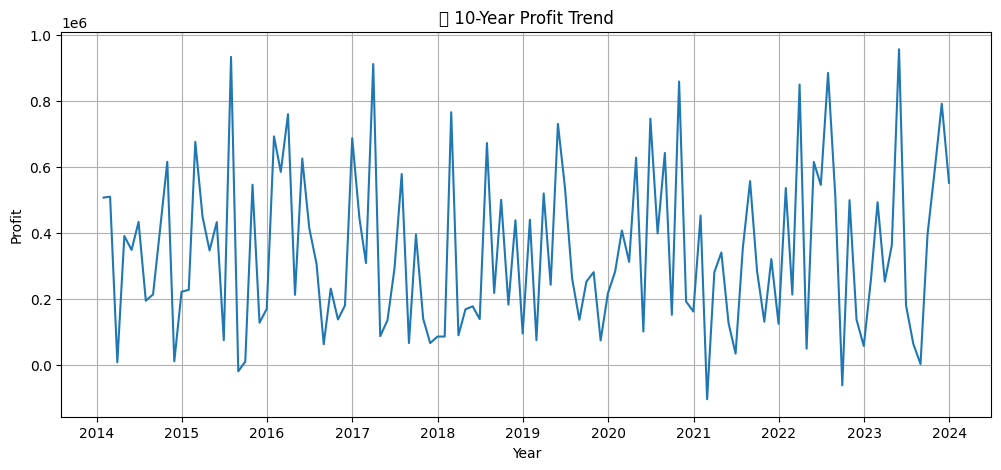

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(data["Date"], data["Profit"])
plt.title("📈 10-Year Profit Trend")
plt.xlabel("Year")
plt.ylabel("Profit")
plt.grid()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


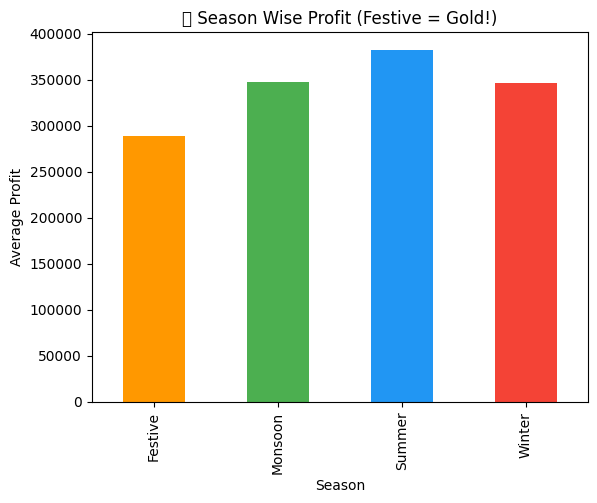

In [14]:
season_profit = data.groupby("Season")["Profit"].mean()

season_profit.plot(kind='bar', color=["#FF9800", "#4CAF50", "#2196F3", "#F44336"])
plt.title("🏆 Season Wise Profit (Festive = Gold!)")
plt.ylabel("Average Profit")
plt.show()

In [15]:
le = LabelEncoder()
data["Season"] = le.fit_transform(data["Season"])

X = data.drop(["Date", "Profit"], axis=1)
y = data["Profit"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Data Ready for ML!")

✅ Data Ready for ML!


In [16]:
models = {
    "Linear": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boost": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = r2_score(y_test, preds)
    results[name] = score
    print(f"{name} Accuracy: {score:.2f}")

best_model = max(results, key=results.get)
print(f"🏆 Best Model: {best_model} with R2 Score of {results[best_model]:.2f}")

Linear Accuracy: 1.00
Random Forest Accuracy: 0.98
Gradient Boost Accuracy: 0.99
XGBoost Accuracy: 0.98
🏆 Best Model: Linear with R2 Score of 1.00


/tmp/ipykernel_5587/296053676.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color='red', lw=2)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


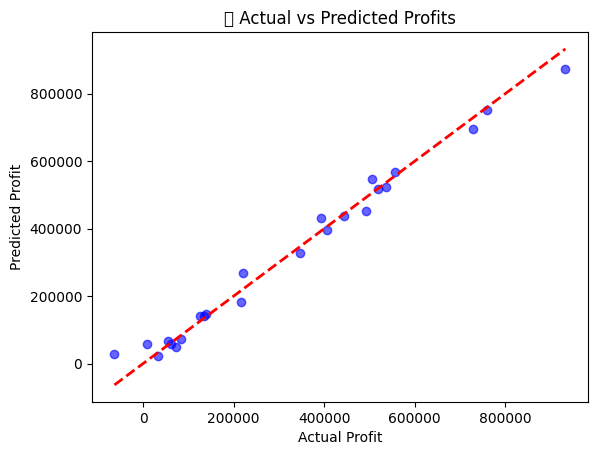

In [17]:
# Define and train the best model
final_model = RandomForestRegressor(random_state=42)
final_model.fit(X_train, y_train)

# Predict profits
final_preds = final_model.predict(X_test)

# Visualization: Actual vs Predicted
plt.scatter(y_test, final_preds, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color='red', lw=2)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("🎯 Actual vs Predicted Profits")
plt.show()

/tmp/ipykernel_5587/1392107656.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=imp_df, palette="Set2")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


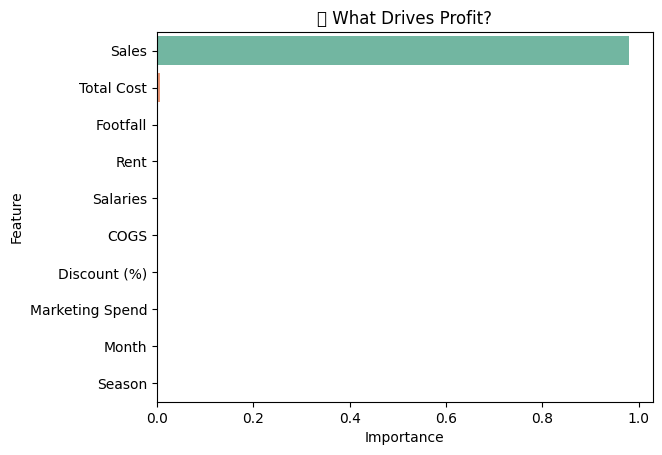

In [18]:
importance = final_model.feature_importances_
features = X.columns

imp_df = pd.DataFrame({"Feature": features, "Importance": importance}).sort_values(by="Importance", ascending=False)

sns.barplot(x="Importance", y="Feature", data=imp_df, palette="Set2")
plt.title("🔥 What Drives Profit?")
plt.show()